# FSB: Filtered-Squared Bispectra

In [1]:
from fsb import *

import pyccl as ccl 
import numpy as np
import healpy as hp
import scipy.stats as st
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs

this is the filters branch


## Data

In [2]:
# let's make some non-gaussian maps 

nside = 256
npix = hp.nside2npix(nside)

def generate_map(cl):

    """
    This function generates a non-gaussian map from a given power 
    spectrum using Lagrangian Perturbation Theory on the 2D sphere
    (Alonso et al. 2015: https://arxiv.org/abs/1512.03402).
    """

    alm = hp.synalm(cl, lmax=3*nside-1)
    
    ls = np.arange(3*nside)
    fl = np.sqrt((ls+2)*(ls+1)*ls*(ls-1))/(ls*(ls+1))
    fl[:2] = 0
    
    elm = hp.almxfl(alm, fl)
    delta = hp.alm2map(alm, nside)
    
    Q, U = hp.alm2map_spin([elm, 0*elm], nside=nside, spin=2, lmax=3*nside-1)

    H11 = 1+0.5*(delta+Q)
    H22 = 1+0.5*(delta-Q)
    H12 = 0.5*U

    return H11*H22-H12**2-1


In [3]:
# multipole range
ells = np.arange(3*nside)

# a realistic survey redshift distribution
z = np.linspace(0.005, 1, 100)
dndz = st.lognorm.pdf(z, 0.4, loc=0.35, scale=.2)

# generate cosmology
cosmo = ccl.CosmologyVanillaLCDM()
bias = 2.0
bz = np.ones_like(z)*bias
tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, dndz), bias=(z, bz))

# compute angular power spectrum
some_standard_cls = ccl.angular_cl(cosmo, tracer, tracer, ells)

In [4]:
# non-gaussian overdensity map
delta = generate_map(some_standard_cls)
delta_cls = hp.anafast(delta) # and corresponding cls (for plotting)

/tmp/ipykernel_3367430/1216093481.py:17: RuntimeWarning: invalid value encountered in divide
  fl = np.sqrt((ls+2)*(ls+1)*ls*(ls-1))/(ls*(ls+1))


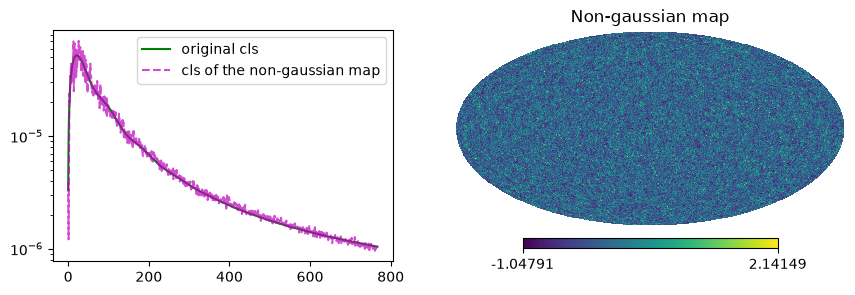

In [5]:
# plotting cls and non-gaussian map

plt.figure(figsize=(11,3))
grid = gs.GridSpec(1,2, width_ratios=[2,3], wspace=0.005)
ax0 = plt.subplot(grid[0])
ax0.semilogy(ells, some_standard_cls, 'g-', label='original cls')
ax0.semilogy(ells, delta_cls, 'm--', label='cls of the non-gaussian map', alpha=0.7)
ax0.legend(loc='upper right')
ax1 = plt.subplot(grid[1])
hp.mollview(delta, hold=True, title='Non-gaussian map')

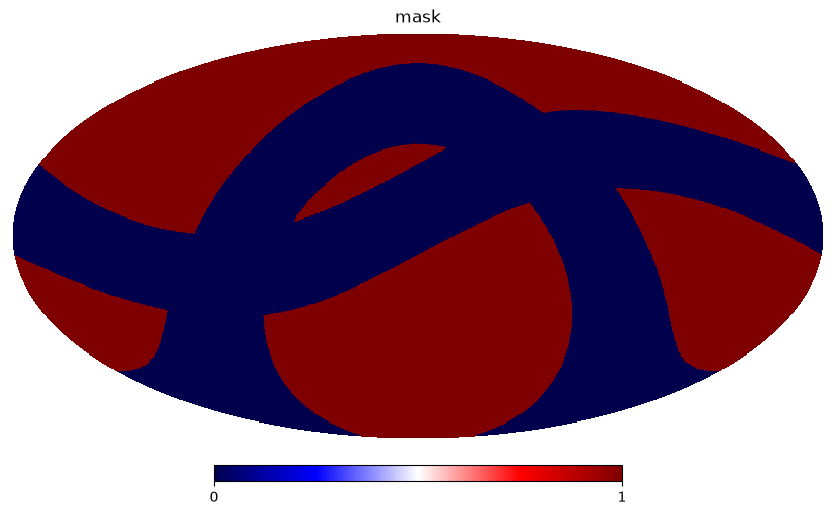

In [6]:
# create a fake mask

# a realistic survey mask
mask = np.ones(hp.nside2npix(nside))
mask[hp.query_strip(nside, 30, 90)] = 0 # mask the galactic plane
mask = hp.Rotator(coord='GC').rotate_map_pixel(mask)
mask[hp.query_strip(nside, 20, 80)] = 0 # mask the ecliptic plane
mask = hp.Rotator(coord='CE').rotate_map_pixel(mask)
mask = mask>0 # ensure the mask is binary

hp.mollview(mask, cmap='seismic', title='mask')

In [7]:
# save map and mask here for easy read
hp.write_map('test_map.fits', delta)
hp.write_map('test_mask.fits', mask)

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('bool')]


## FSB signal

In [2]:
# defining some parameters
nside = 256

# ells per bandpower
lpb = 17

# FSB filters
nbands = 3
fls = get_filters(nbands, nside)

# plt.figure(); 
# for f in fls:
#     plt.plot(ells, f)
# plt.xlabel(r"$\ell$")
# plt.ylabel(r"$F_\ell$")

combi = np.ones((len(fls), len(fls)))
combi = np.triu(combi) # only upper triangle to not repeat filter combinations
print(combi)

[[1. 1. 1.]
 [0. 1. 1.]
 [0. 0. 1.]]


In [3]:
# data
delta = hp.read_map('test_map.fits')
mask = hp.read_map('test_mask.fits')
delta = (delta-np.mean(delta[mask==1]))*mask # - mean inside mask

In [4]:
# initiating FSB class, which will contain all quantities needed to compute the FSB and its covariance
fsb_test = FSB(delta, mask1=mask, filters=fls, filter_combinations = combi, ells_per_bin=lpb)

(6, 45)


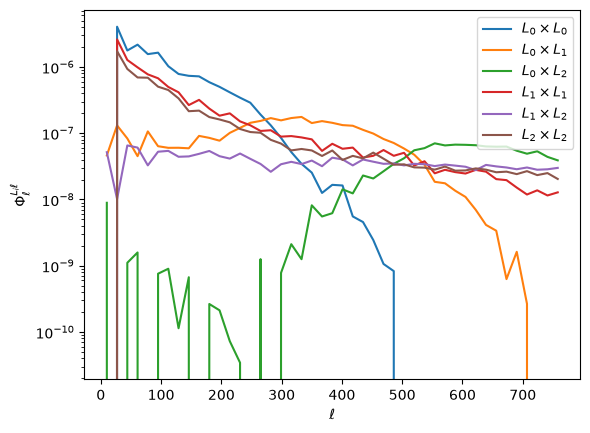

In [5]:
# let's plot the FSBs
print(fsb_test.fsb_binned.shape)

for i, f in enumerate(fsb_test.fsb_binned):
    plt.semilogy(fsb_test.bb.get_effective_ells(), f, label=r'$L_{0} \times L_{1}$'.format(fsb_test.filt_i[i], fsb_test.filt_j[i]))
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\Phi_\ell^{L_i \ell}$')
plt.legend()

In [9]:
# plt.semilogy(fsb_test.datavector())
# plt.semilogy(fsb_test.datavector(cl_auto=False))

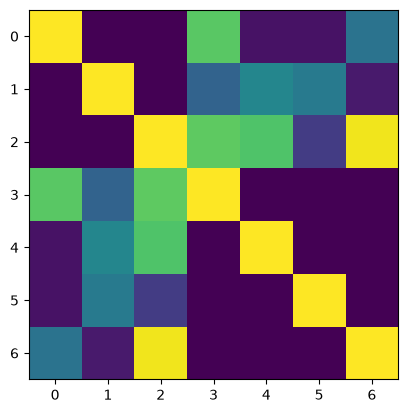

In [14]:
trois = np.eye(3)
quatre = np.eye(4)
mix = np.random.random(size=(3,4))
mixt = mix.T 

tgt = [[trois, mix], [mixt, quatre]]

plt.imshow(np.block(tgt))

## FSB covariance

In [9]:
# analytical covariance
# (includes disconnected covariance + non gaussian terms N222 and N32)
anacov = fsb_test.get_cov_auto(n222=False, n32=False) # as simple as that (may take a while though)

In [10]:
anacov.shape

(7, 7, 45, 45)

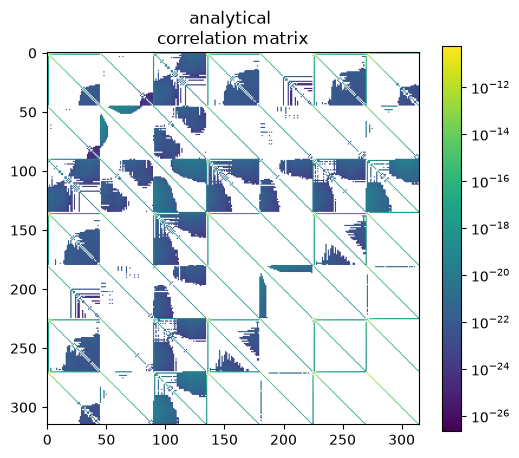

In [16]:
def cor(cov):
    
    """
    This function returns the correlation matrix
    corresponding to the covariance matrix.
    """

    return cov/np.sqrt(np.outer(np.diag(cov), np.diag(cov)))  

def _reduce2(bigm):
    """
    Reduces the dimensionality of an array by 2 along its first two axes.

    Arguments
    ----------
    bigm : array with shape (i, j, k, ...)

    Returns
    ----------
    An array of shape (k, ...)

    """
    minus1 = np.hstack(tuple(l for l in bigm)); # print(minus1.shape)
    minus2 = np.hstack(tuple(l for l in minus1)); # print(minus2.shape)
    return minus2

anacor = _reduce2(anacov) # cor(_reduce2(anacov))
mini = np.min(anacor)
maxi = np.max(anacor)

plt.figure(figsize=(6,5))
# plt.imshow(anacor, vmin=mini, vmax=maxi, norm='log')
plt.imshow(anacor, norm='log')
plt.title('analytical \ncorrelation matrix')
plt.colorbar(); 